In [1]:
from src.dataset import load_dataset
from sklearn.model_selection import train_test_split
from polynomial_regression import PolynomialRegression
import numpy as np
from probabilistic_rf_scoring import get_regression_score
from pdf import choose_pdf, plot_curves
import pandas as pd
import matplotlib.pyplot as plt
import os
import joblib

In [2]:
TRAIN_SPLIT=0.85
TEST_SPLIT=0.15
TRAIN_PATH_X = "../../../data/processed/train/train_trqMargin.csv"
RESIDUI_PATH = f"../../../output/polynomial_regression/residui_margin_train{TRAIN_SPLIT}_test{TEST_SPLIT}"
OUTPUT_PATH="../../../output/polynomial_regression/model_margin/"
MODEL_PATH="polynomial_regression_model_margin.pkl"
RESIDUI_CSV="/residui.csv"
TARGET_COL = "trq_margin"
DEGREE = {1,2,3}
ITERATIONS = 1000


Degree  1
MAE: 1.7584821154403263
MSE: 5.505186258526457
RMSE: 2.346313333407637
R²: 0.9727871269165224


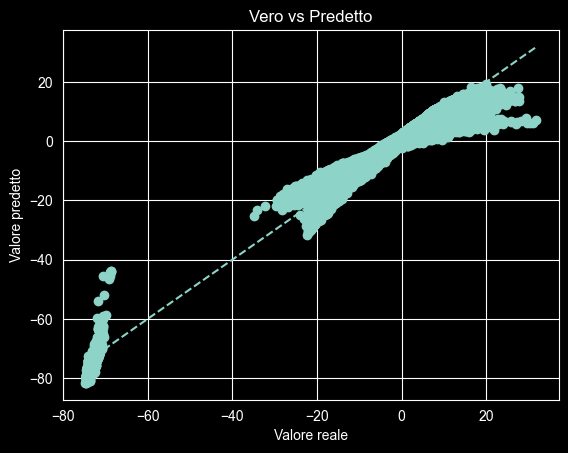


Degree  2
MAE: 0.33102570231965267
MSE: 0.277968966859962
RMSE: 0.5272276233847786
R²: 0.99862596216348


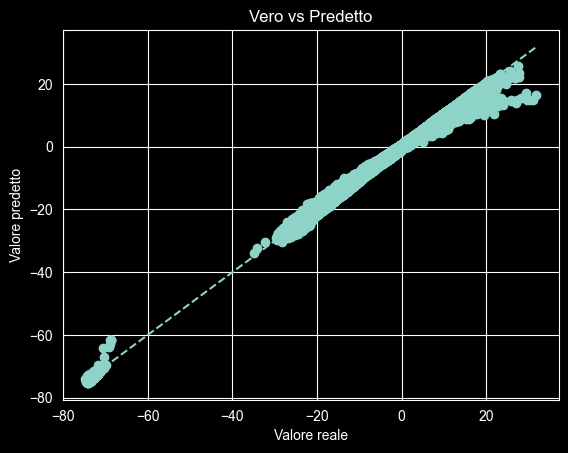


Degree  3
MAE: 0.08837557535416984
MSE: 0.027038666081477092
RMSE: 0.16443438229724675
R²: 0.9998663442517894


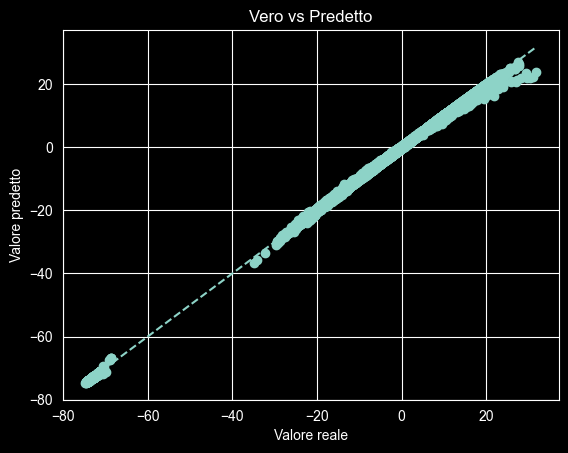

In [3]:
train_data = pd.read_csv(TRAIN_PATH_X)

train_df, test_df = train_test_split(
    train_data,
    test_size=TEST_SPLIT,
    random_state=42,
    shuffle=True
)

drop_cols = [TARGET_COL]
X_cols = [c for c in train_df.columns if c not in drop_cols]

X_train = train_df[X_cols].values
y_train = train_df[TARGET_COL].values

X_test = test_df[X_cols].values
y_test = test_df[TARGET_COL].values

for degree in DEGREE:
    model = PolynomialRegression(degree=degree)
    model.fit(X_train, y_train)
    print("\n"+"Degree ", degree)
    model.evaluate_regression(X_test, y_test)

    y_pred = model.predict(X_test)

    plt.figure()
    plt.scatter(y_test, y_pred)
    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        linestyle="--"
    )
    plt.xlabel("Valore reale")
    plt.ylabel("Valore predetto")
    plt.title("Vero vs Predetto")
    plt.show()

In [4]:
model = PolynomialRegression(degree=3)
if os.path.exists(OUTPUT_PATH+MODEL_PATH):
    model= joblib.load(OUTPUT_PATH+MODEL_PATH)
else:
  model.fit(X_train, y_train)
  joblib.dump(model, OUTPUT_PATH + MODEL_PATH)

In [5]:
if os.path.exists(not RESIDUI_PATH+RESIDUI_CSV):
    model.compute_residuals(X_train,y_train,path=RESIDUI_PATH)

In [6]:
residui = load_dataset(RESIDUI_PATH + RESIDUI_CSV)

test_row = test_df.iloc[1231]
test_x = test_row[X_cols].to_frame().T
test_y_true =test_row[TARGET_COL]
trq_margin_pred = model.predict(test_x)[0]

rows = []
for m in range(ITERATIONS):
    residual = residui.sample(n=1)["residual"].iloc[0]
    rows.append({"trq_margin_probability": trq_margin_pred + residual})

distribution = pd.DataFrame(rows)
distribution.head()

,trq_margin_probability
0,3.704235
1,3.684152
2,3.784381
3,3.858635
4,3.696232


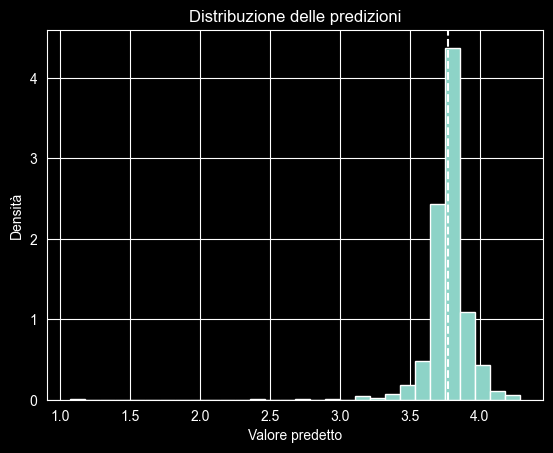

In [7]:
plt.figure()
plt.hist(distribution["trq_margin_probability"], bins=30, density=True)
plt.axvline(trq_margin_pred, linestyle="--", label="Predizione puntuale")
plt.xlabel("Valore predetto")
plt.xlabel("Valore predetto")
plt.ylabel("Densità")
plt.title("Distribuzione delle predizioni")
plt.show()

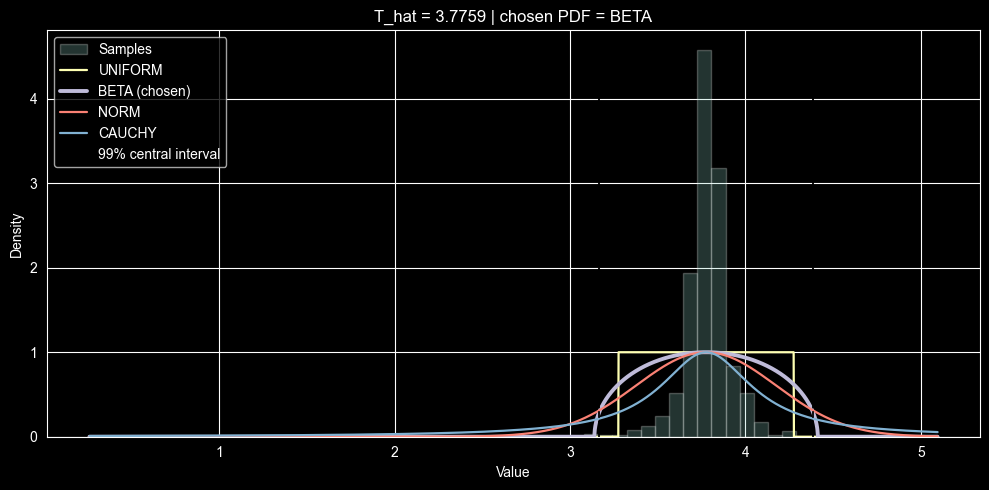

PDF scelta: beta
Score: 0.9999807868492909


In [8]:
trq_margin_mean=np.mean(distribution["trq_margin_probability"])
pdf_type, pdf_args,_ = choose_pdf(distribution["trq_margin_probability"], trq_margin_mean)
score = get_regression_score(pdf_type, pdf_args,test_y_true)
plot_curves(distribution["trq_margin_probability"], trq_margin_mean, pdf_type)

print("PDF scelta:", pdf_type)
print("Score:", score)